<a href="https://colab.research.google.com/github/ihlasnijam/Northstar-analytics/blob/main/Northstar_Analytics_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Load all files
customers  = pd.read_csv('customers.csv',
                parse_dates=['signup_date'])
orders     = pd.read_csv('orders.csv',
                parse_dates=['order_created_at'])
deliveries = pd.read_csv('deliveries.csv',
                parse_dates=['dispatch_time',
                             'delivery_completed_at'])
drivers    = pd.read_csv('drivers.csv')
vehicles   = pd.read_csv('vehicles.csv',
                parse_dates=['commission_date'])
hubs       = pd.read_csv('hubs.csv')
complaints = pd.read_csv('complaints.csv',
                parse_dates=['created_at'])
incidents  = pd.read_csv('incidents.csv',
                parse_dates=['reported_at'])
app_events = pd.read_csv('app_events.csv',
                parse_dates=['event_timestamp'])

print('All files loaded.')
for name, df in [('customers',customers),('orders',orders),
    ('deliveries',deliveries),('drivers',drivers),
    ('vehicles',vehicles),('hubs',hubs),
    ('complaints',complaints),('incidents',incidents),
    ('app_events',app_events)]:
    print(f'  {name}: {df.shape[0]:,} rows x {df.shape[1]} cols')


All files loaded.
  customers: 650 rows x 9 cols
  orders: 1,250 rows x 11 cols
  deliveries: 950 rows x 13 cols
  drivers: 170 rows x 8 cols
  vehicles: 120 rows x 8 cols
  hubs: 8 rows x 5 cols
  complaints: 320 rows x 10 cols
  incidents: 280 rows x 7 cols
  app_events: 640 rows x 10 cols


In [ ]:
zone_map = {
    'AIRPORT':'Airport', 'airport':'Airport',
    'CENTRAL':'Central', 'central':'Central',
    'Ctr':'Central',     'ctr':'Central',
    'NORTH':'North',     'north':'North',
    'SOUTH':'South',     'south':'South',
    'EAST':'East',       'east':'East',
    'WEST':'West',       'west':'West',
    'RIVERSIDE':'Riverside','riverside':'Riverside',
    'RiverSide':'Riverside'
}

zone_cols = {
    'customers': ['home_zone'],
    'orders':    ['pickup_zone','dropoff_zone'],
    'drivers':   ['base_zone'],
    'vehicles':  ['assigned_zone']
}
dfs = {'customers':customers,'orders':orders,
       'drivers':drivers,'vehicles':vehicles}

for df_name, cols in zone_cols.items():
    for col in cols:
        dfs[df_name][col] = dfs[df_name][col].replace(zone_map)

# Verify canonical zones
canonical = {'Airport','Central','North','South','East','West','Riverside'}
for df_name, cols in zone_cols.items():
    for col in cols:
        remaining = set(dfs[df_name][col].dropna()) - canonical
        status = 'OK' if not remaining else f'Issues: {remaining}'
        print(f'  {df_name}.{col}: {status}')


  customers.home_zone: OK
  orders.pickup_zone: OK
  orders.dropoff_zone: OK
  drivers.base_zone: OK
  vehicles.assigned_zone: OK


In [ ]:
# Missing value audit
print('=== Missing values ===')
for name, df in [('customers',customers),('orders',orders),
    ('deliveries',deliveries),('drivers',drivers),
    ('vehicles',vehicles),('complaints',complaints),
    ('incidents',incidents),('app_events',app_events)]:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls):
        print(f'\n{name}:')
        for col, cnt in nulls.items():
            print(f'  {col}: {cnt} ({100*cnt/len(df):.1f}%)')

# Numeric: median imputation
for col in ['loyalty_score','app_engagement_score']:
    customers[col].fillna(customers[col].median(), inplace=True)

drivers['training_score'].fillna(
    drivers['training_score'].median(), inplace=True)
vehicles['battery_health_pct'].fillna(
    vehicles['battery_health_pct'].median(), inplace=True)
deliveries['customer_rating_post_delivery'].fillna(
    deliveries['customer_rating_post_delivery'].median(), inplace=True)

# Categorical: mode imputation
customers['preferred_channel'].fillna(
    customers['preferred_channel'].mode()[0], inplace=True)
orders['booking_channel'].fillna(
    orders['booking_channel'].mode()[0], inplace=True)

print('Imputation complete.')


=== Missing values ===

deliveries:
  delivery_completed_at: 19 (2.0%)

complaints:
  compensation_amount: 16 (5.0%)

incidents:
  resolved_hours: 17 (6.1%)

app_events:
  order_id: 144 (22.5%)
Imputation complete.


/tmp/ipykernel_3298/2762218368.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customers[col].fillna(customers[col].median(), inplace=True)
/tmp/ipykernel_3298/2762218368.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [ ]:
# Merge all structured files
master = (deliveries
    .merge(orders,    on='order_id',    how='left')
    .merge(drivers,   on='driver_id',   how='left')
    .merge(vehicles,  on='vehicle_id',  how='left')
    .merge(hubs,      on='hub_id',      how='left')
    .merge(customers, on='customer_id', how='left')
)

print(f'Master: {master.shape[0]:,} rows x {master.shape[1]} cols')

# Data integrity checks
assert master['delivery_id'].duplicated().sum() == 0, \
    'Duplicate delivery IDs found!'
assert len(master) == len(deliveries), \
    'Row count mismatch after merge!'
print('Integrity checks passed.')


Master: 950 rows x 49 cols
Integrity checks passed.


In [ ]:
# Delivery duration and delay
master['actual_hours'] = (
    (master['delivery_completed_at'] - master['dispatch_time'])
    .dt.total_seconds() / 3600
)

master['delay_hours']  = (master['actual_hours'] -
                           master['promised_window_hours'])
master['is_late']      = ((master['delay_hours'] > 0) &
    (master['delivery_status'] != 'Failed')).astype(int)
master['is_failed']    = (
    master['delivery_status'] == 'Failed').astype(int)
master['has_override'] = (
    master['manual_route_override_count'] > 0).astype(int)
master['cost_per_km']  = np.where(
    master['route_distance_km'] > 0,
    master['fuel_or_charge_cost'] / master['route_distance_km'],
    np.nan
)

# Remove impossible durations
master = master[
    master['actual_hours'].isna() | (master['actual_hours'] >= 0)
].copy()

# NumPy statistics
for col in ['actual_hours','delay_hours',
            'cost_per_km',
            'customer_rating_post_delivery']:
    arr = master[col].dropna().values
    print(f'\n{col}:')
    print(f'  mean={np.mean(arr):.3f}  median={np.median(arr):.3f}')
    print(f'  std={np.std(arr):.3f}  p25={np.percentile(arr,25):.3f} p75={np.percentile(arr,75):.3f}')



actual_hours:
  mean=10.317  median=7.913
  std=8.458  p25=3.502 p75=15.528

delay_hours:
  mean=2.326  median=0.017
  std=5.583  p25=-1.668 p75=5.400

cost_per_km:
  mean=1.249  median=0.948
  std=1.208  p25=0.702 p75=1.329

customer_rating_post_delivery:
  mean=3.844  median=4.030
  std=0.899  p25=3.340 p75=4.537


In [ ]:
# Zone-level performance
zone_summary = master.groupby('pickup_zone').agg(
    total_deliveries = ('delivery_id','count'),
    failed           = ('is_failed','sum'),
    failure_rate_pct = ('is_failed',
        lambda x: round(x.mean()*100,1)),
    avg_delay_hrs    = ('delay_hours',
        lambda x: round(x[x>0].mean(),2)),
    avg_cost_per_km  = ('cost_per_km',
        lambda x: round(x.mean(),3)),
    override_rate    = ('has_override',
        lambda x: round(x.mean()*100,1))
).reset_index().sort_values('failure_rate_pct',ascending=False)

print(zone_summary.to_string(index=False))

# Service type profitability
service_summary = master.groupby('service_type').agg(
    orders              = ('order_id','nunique'),
    avg_order_value     = ('order_value','mean'),
    avg_cost            = ('fuel_or_charge_cost','mean'),
    avg_cost_per_km     = ('cost_per_km','mean'),
    failure_rate_pct    = ('is_failed',
        lambda x: round(x.mean()*100,1)),
    avg_customer_rating = ('customer_rating_post_delivery','mean')
).round(2).reset_index()

print(service_summary.to_string(index=False))


pickup_zone  total_deliveries  failed  failure_rate_pct  avg_delay_hrs  avg_cost_per_km  override_rate
    Central               164      33              20.1           7.48            1.278           67.1
      North               128      22              17.2           6.14            1.355           48.4
  Riverside               112      18              16.1           7.56            1.395           46.4
       West               103      14              13.6           6.21            1.235           57.3
       East               145      19              13.1           5.33            1.332           50.3
    Airport               106      12              11.3           5.87            0.624           84.0
      South               128      14              10.9           5.85            1.416           52.3
service_type  orders  avg_order_value  avg_cost  avg_cost_per_km  failure_rate_pct  avg_customer_rating
    Business     116            97.04     13.15             1.24        

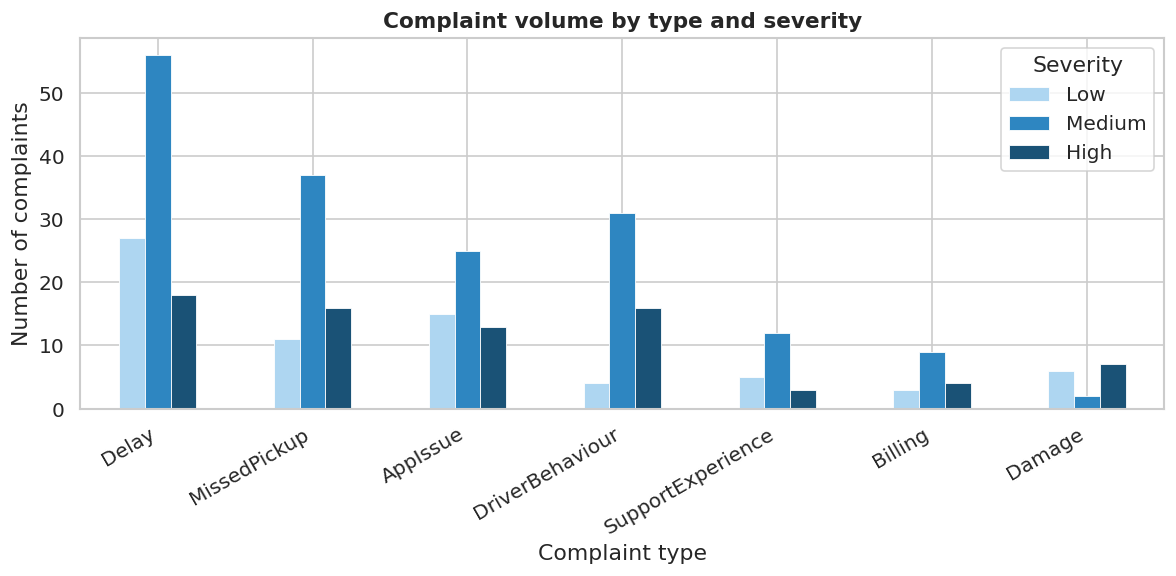

In [ ]:
complaint_pivot = (complaints
    .groupby(['complaint_type','severity'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['Low','Medium','High'],fill_value=0))
complaint_pivot = complaint_pivot.loc[
    complaint_pivot.sum(axis=1)
    .sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10,5))
complaint_pivot.plot(kind='bar', ax=ax,
    color=['#AED6F1','#2E86C1','#1A5276'],
    edgecolor='white', linewidth=0.5)
ax.set_title('Complaint volume by type and severity',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Complaint type')
ax.set_ylabel('Number of complaints')
ax.set_xticklabels(ax.get_xticklabels(),
                   rotation=30, ha='right')
ax.legend(title='Severity')
plt.tight_layout()
plt.savefig('plot7_complaints.png', dpi=150)
plt.show()


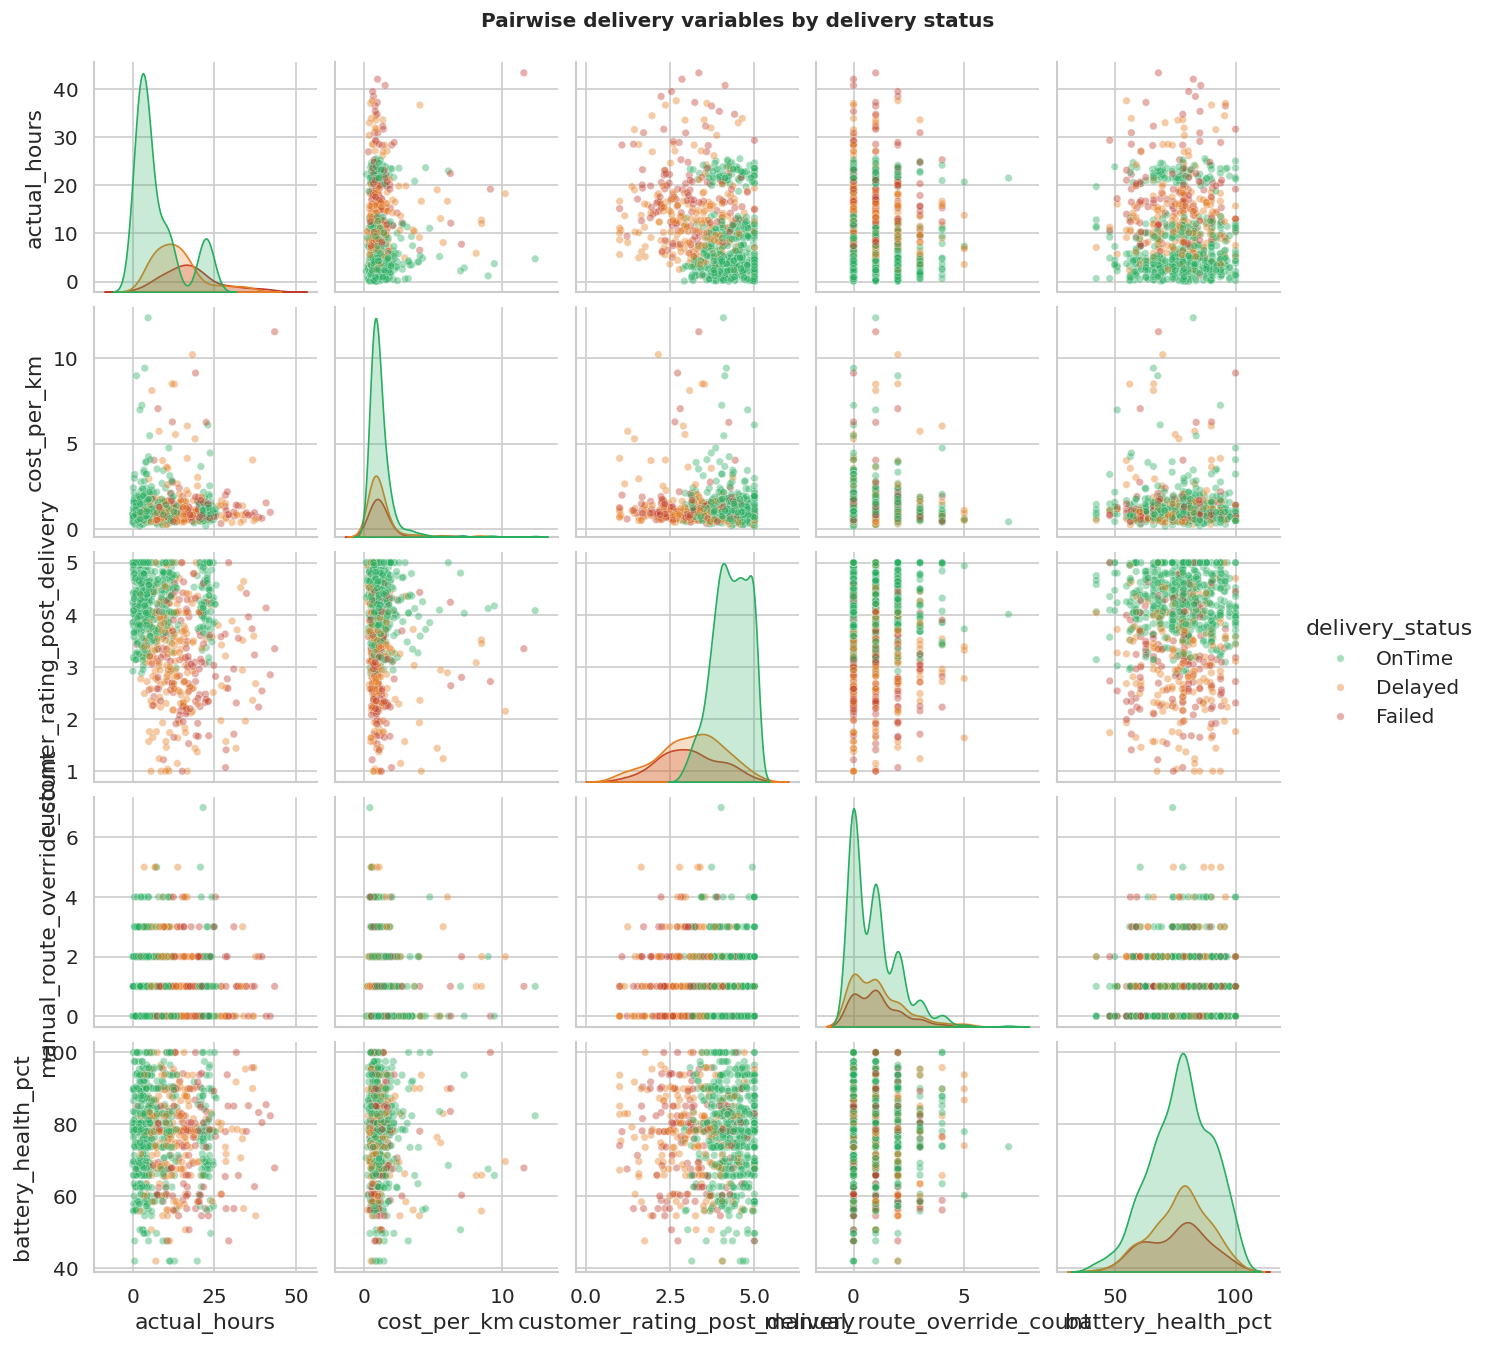

In [ ]:
pair_vars = master[[
    'actual_hours','cost_per_km',
    'customer_rating_post_delivery',
    'manual_route_override_count',
    'battery_health_pct',
    'delivery_status']].dropna()

g = sns.pairplot(
    pair_vars,
    hue       = 'delivery_status',
    hue_order = ['OnTime','Delayed','Failed'],
    palette   = {'OnTime':'#27AE60',
                 'Delayed':'#E67E22',
                 'Failed':'#C0392B'},
    diag_kind = 'kde',
    plot_kws  = {'alpha':0.4, 's':20},
    height    = 2.2
)
g.fig.suptitle(
    'Pairwise delivery variables by delivery status',
    y=1.02, fontsize=12, fontweight='bold')
plt.savefig('plot8_pairplot.png', dpi=120,
            bbox_inches='tight')
plt.show()


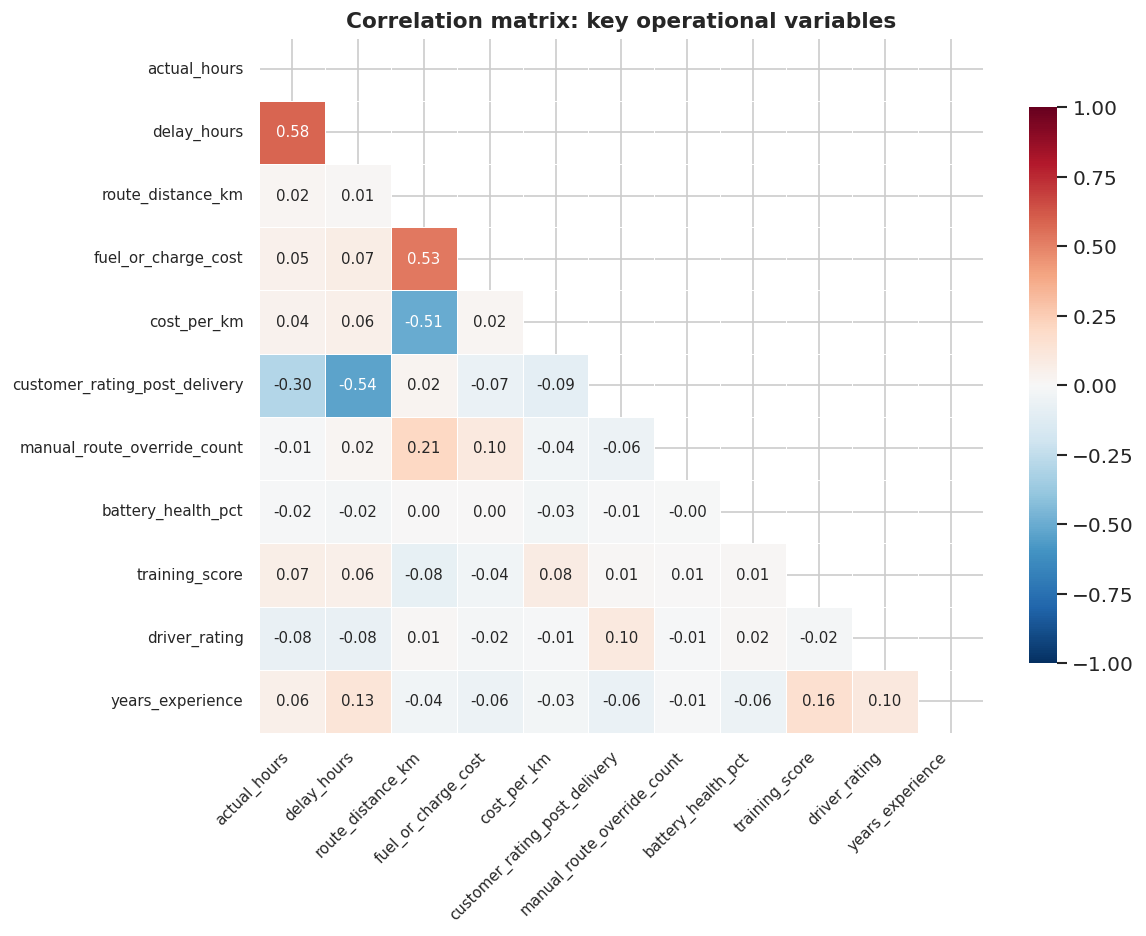

In [ ]:
heat_vars = master[[
    'actual_hours','delay_hours',
    'route_distance_km','fuel_or_charge_cost',
    'cost_per_km','customer_rating_post_delivery',
    'manual_route_override_count',
    'battery_health_pct','training_score',
    'driver_rating','years_experience'
]].dropna()

corr = heat_vars.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(
    corr, mask=mask, ax=ax,
    annot=True, fmt='.2f', annot_kws={'size':9},
    cmap='RdBu_r', vmin=-1, vmax=1, center=0,
    linewidths=0.5, linecolor='white',
    cbar_kws={'shrink':0.8}
)
ax.set_title('Correlation matrix: key operational variables',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(),
                   rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(),
                   rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('plot9_heatmap.png', dpi=150)
plt.show()


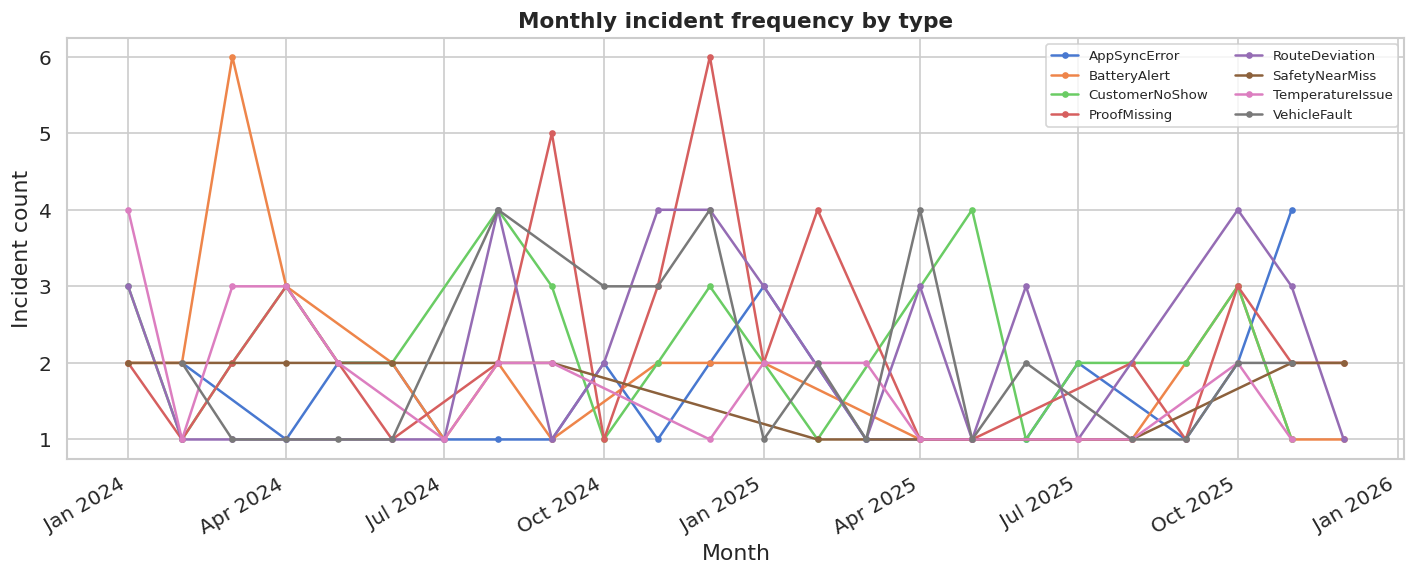

In [ ]:
incidents['month'] = (incidents['reported_at']
    .dt.to_period('M').dt.to_timestamp())
incident_trend = (incidents
    .groupby(['month','incident_type'])
    .size().reset_index(name='count'))

fig, ax = plt.subplots(figsize=(12,5))
for itype, grp in incident_trend.groupby('incident_type'):
    ax.plot(grp['month'], grp['count'],
            marker='o', markersize=3,
            linewidth=1.5, label=itype)

ax.set_title('Monthly incident frequency by type',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Incident count')
ax.legend(fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(
    plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('plot10_incidents.png', dpi=150)
plt.show()


Chi-square: chi2=7.24, p=0.2990, dof=6
Association is NOT significant


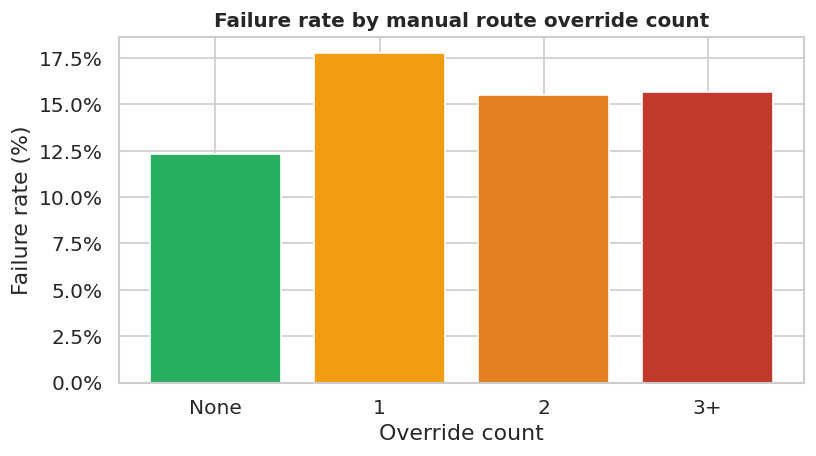

In [19]:
# Bucket override counts for chi-square test
import matplotlib.ticker as mtick
master['override_bucket'] = pd.cut(
    master['manual_route_override_count'],
    bins=[-1,0,1,2,10], labels=['None','1','2','3+'])

contingency = pd.crosstab(master['override_bucket'], master['delivery_status'])
chi2, pval, dof, _ = stats.chi2_contingency(contingency)
print(f'Chi-square: chi2={chi2:.2f}, p={pval:.4f}, dof={dof}')
print('Association is', 'SIGNIFICANT' if pval < 0.05 else 'NOT significant')

fail_by_ov = master.groupby('override_bucket', observed=True)['is_failed'].mean().reset_index()
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(fail_by_ov['override_bucket'].astype(str),
       fail_by_ov['is_failed']*100,
       color=['#27AE60','#F39C12','#E67E22','#C0392B'])
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Failure rate by manual route override count',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Override count'); ax.set_ylabel('Failure rate (%)')
plt.tight_layout(); plt.show()
